In [13]:
import os, glob
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "/lustre/scratch126/cellgen/lotfollahi/dj16/data/public_serial_sections/"

# HER2 3D Serial-Section Data — Exploration & Visualization

Dataset: **`HER2_3D`** (public HER2+ breast-cancer serial-section spatial transcriptomics, Andersson et al. 2021, *Nat Commun*,
https://www.nature.com/articles/s41467-021-26271-2#Sec22.)

What this notebook covers:
1. **Loading the data** — directory layout and how to load it
2. **What the samples are** — sample / section composition
3. **Visualizing the sections** — spatial spot maps + H&E patches
4. **Distance between sections** — in-plane spot pitch & through-plane (z) spacing (with measurements)

In [14]:
DATA_HER2 = Path(DATA) / "HER2_3D"

In [15]:
NPY  = os.path.join(DATA_HER2, "npy_information")   # per-section spot dicts (.npy)

print("HER2_3D subdirectories:")
for d in sorted(os.listdir(DATA)):
    print("  ", d)

HER2_3D subdirectories:
   .claude
   DLPFC
   DLPFC_3D
   HER2.zip
   HER2_3D
   ST_Breast_3D
   STdata.zip
   data_source.md
   spatialLIBD-biorRxiv.zip


## 1. Directory layout

| Path | Contents |
|------|----------|
| `npy_information/<sample>/<section>.npy` | **Per-section spot list** (array of dicts) — the main thing we use |
| `graph_data/<sample>/<section>.pt` | Per-section multi-scale graph (torch_geometric `HeteroData`, layers 224/512/1024) |
| `3D_graph_data/<sample>.pt` | Whole-sample 3D graph (all sections combined) |
| `3D_npy_information/<sample>.npy` | Whole-sample spot list + `level` (section ordinal) field |
| `3D_combined_information/<sample>.csv` | spot x spot similarity (correlation) matrix — used to build 3D graph edges |
| `cropped_imgs/patch_{224,512,1024}/` | H&E image patches at each spot location |

In [16]:
def list_sections():
    out = {}
    for s in sorted(os.listdir(NPY)):
        secs = sorted(os.path.basename(f)[:-4]
                      for f in glob.glob(os.path.join(NPY, s, "*.npy")))
        out[s] = secs
    return out

samples = list_sections()
for s, secs in samples.items():
    print(f"{s}: {len(secs)} sections -> {secs}")

print("\nTotal", sum(len(v) for v in samples.values()), "sections /",
      len(samples), "samples")

A: 6 sections -> ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
B: 6 sections -> ['B1', 'B2', 'B3', 'B4', 'B5', 'B6']
C: 6 sections -> ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
D: 6 sections -> ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
E: 3 sections -> ['E1', 'E2', 'E3']
F: 3 sections -> ['F1', 'F2', 'F3']
G: 3 sections -> ['G1', 'G2', 'G3']
H: 3 sections -> ['H1', 'H2', 'H3']

Total 36 sections / 8 samples


## 2. What are the samples?

- **Samples A-H = 8 HER2+ breast-cancer tumors**. Each sample is a stack of **serial sections** cut from one tumor block.
- **A-D**: **6 sections** each — described in the original paper as *"evenly spaced alternative sections"*. --> 32um gap between sections
- **E-H**: **3 sections** each — *"adjacent"*. --> 16um gap between sections
- One **spot** = a single ST-platform spot (100 um pitch); each spot carries:
  - `label` : expression of 250 genes (log-normalized) — the 3D-reconstruction target
  - `position` : `[x, y]` ST array grid coordinate (integers)
  - `feature_512`, `feature_1024` : H&E image embeddings for the patch at that spot (1024-d)
  - `label_512`, `label_1024` : expression pooled at larger patch scales
  - `img_path` : path to the H&E patch image

> Note: the `.npy` files store no physical unit (um), only the section ordinal (the `level` field in the 3D npy).

In [17]:
def load_section(sample, section):
    """Return the list of spot dicts for one section."""
    path = os.path.join(NPY, sample, f"{section}.npy")
    return list(np.load(path, allow_pickle=True))

A1 = load_section("A", "A1")
spot = A1[0]
print("number of spots in section A1:", len(A1), "\n")
print("fields of one spot (dict):")
for k, v in spot.items():
    if k in ("img_path", "position"):
        print(f"  {k:12s} = {v}")
    else:
        print(f"  {k:12s} : ndarray shape {np.asarray(v).shape}")

number of spots in section A1: 346 

fields of one spot (dict):
  img_path     = cropped_imgs/patch_224/A1/10x13.png
  label        : ndarray shape (250,)
  position     = [10, 13]
  feature_1024 : ndarray shape (1024,)
  feature_512  : ndarray shape (1024,)
  label_1024   : ndarray shape (250,)
  label_512    : ndarray shape (250,)


In [18]:
# Summary table across all samples / sections
rows = []
for s, secs in samples.items():
    for sec in secs:
        d = load_section(s, sec)
        pos = np.array([x['position'] for x in d])
        rows.append(dict(sample=s, section=sec, n_spots=len(d),
                         x_range=f"{pos[:,0].min()}-{pos[:,0].max()}",
                         y_range=f"{pos[:,1].min()}-{pos[:,1].max()}",
                         n_genes=np.asarray(d[0]['label']).shape[0]))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print("\nPer-sample aggregate:")
agg = (summary.groupby('sample')
       .agg(n_sections=('section','count'),
            total_spots=('n_spots','sum'),
            mean_spots=('n_spots','mean')))
print(agg.to_string())

sample section  n_spots x_range y_range  n_genes
     A      A1      346    3-26   12-28      250
     A      A2      325    2-24   15-30      250
     A      A3      359    6-30   11-27      250
     A      A4      343    2-26   10-26      250
     A      A5      332    4-27   16-31      250
     A      A6      360    3-27   14-31      250
     B      B1      295    2-24   11-31      250
     B      B2      270    2-25   14-32      250
     B      B3      298    3-26   13-33      250
     B      B4      283    6-29   13-31      250
     B      B5      289    2-25    6-26      250
     B      B6      277    4-28   11-31      250
     C      C1      176    5-23   10-25      250
     C      C2      187    9-28   13-29      250
     C      C3      180    4-23    5-20      250
     C      C4      184    3-23    8-23      250
     C      C5      181    3-23    6-21      250
     C      C6      178    2-22    9-25      250
     D      D1      306    4-22   10-28      250
     D      D2      

## 3. Visualizing the sections

Each spot is plotted at its `position` (x, y) and colored by its **mean expression** over the 250 genes.
Because these are serial sections, they are consecutive layers of the same tumor and share the same grid coordinate frame.

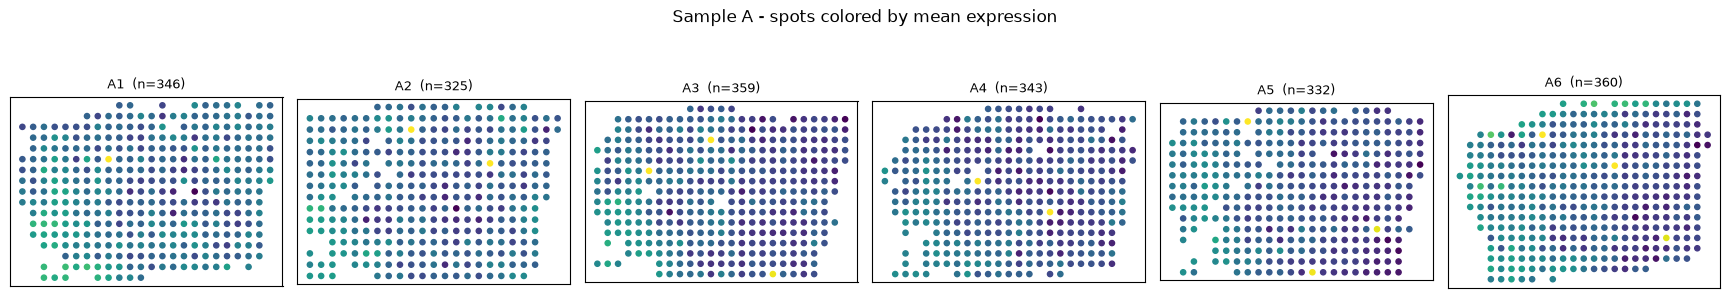

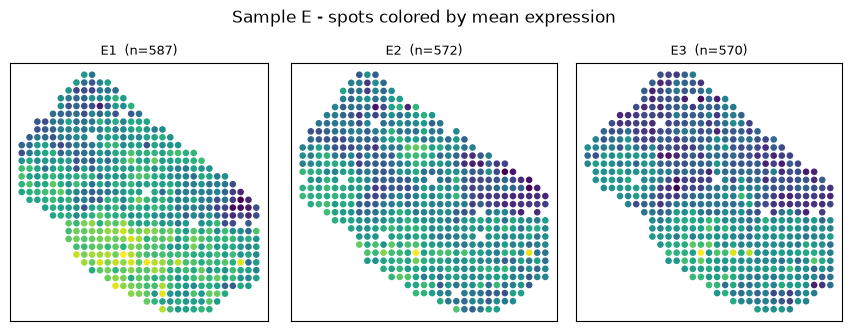

In [19]:
def plot_sample_sections(sample, color_gene=None):
    secs = samples[sample]
    fig, axes = plt.subplots(1, len(secs), figsize=(2.9*len(secs), 3.2), squeeze=False)
    for ax, sec in zip(axes[0], secs):
        d = load_section(sample, sec)
        pos = np.array([x['position'] for x in d], float)
        lab = np.array([x['label'] for x in d], float)      # (n, 250)
        c = lab[:, color_gene] if color_gene is not None else lab.mean(1)
        ax.scatter(pos[:,0], pos[:,1], c=c, s=14, cmap='viridis')
        ax.set_title(f"{sec}  (n={len(d)})", fontsize=9)
        ax.set_aspect('equal'); ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([])
    ttl = f"gene[{color_gene}]" if color_gene is not None else "mean expression"
    fig.suptitle(f"Sample {sample} - spots colored by {ttl}", y=1.02)
    fig.tight_layout(); plt.show()

plot_sample_sections("A")   # 6 sections (evenly spaced)
plot_sample_sections("E")   # 3 sections (adjacent)

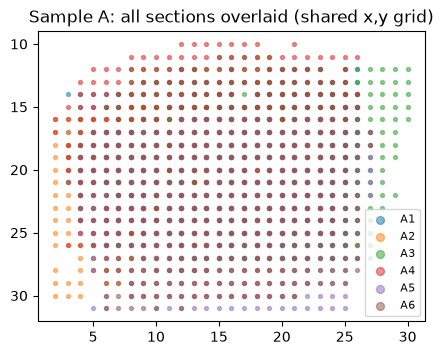

In [20]:
# Overlay all sections of one sample to check the shared coordinate frame (alignment)
def overlay_sections(sample):
    plt.figure(figsize=(5,5))
    for sec in samples[sample]:
        d = load_section(sample, sec)
        pos = np.array([x['position'] for x in d], float)
        plt.scatter(pos[:,0], pos[:,1], s=8, alpha=0.5, label=sec)
    plt.gca().set_aspect('equal'); plt.gca().invert_yaxis()
    plt.legend(markerscale=2, fontsize=8)
    plt.title(f"Sample {sample}: all sections overlaid (shared x,y grid)")
    plt.show()

overlay_sections("A")

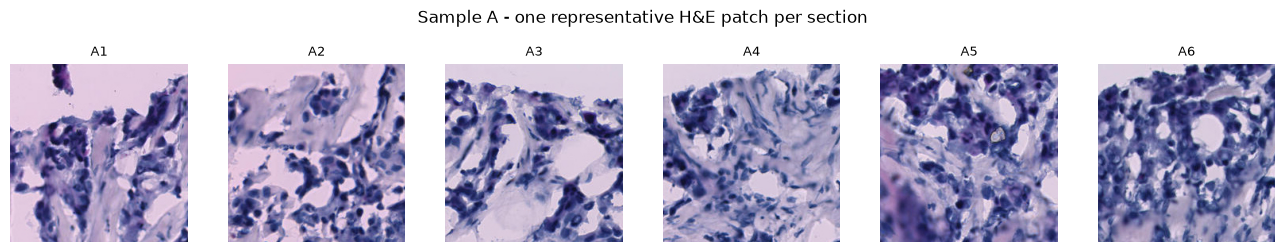

In [21]:
# One representative H&E patch per section
from PIL import Image
secs = samples["A"]
fig, axes = plt.subplots(1, len(secs), figsize=(2.2*len(secs), 2.4))
for ax, sec in zip(np.atleast_1d(axes), secs):
    d = load_section("A", sec)
    img = Image.open(os.path.join(DATA_HER2, d[0]['img_path']))
    ax.imshow(img); ax.set_title(sec, fontsize=9); ax.axis('off')
fig.suptitle("Sample A - one representative H&E patch per section", y=1.03)
plt.tight_layout(); plt.show()

## 4. Distance between sections

Distance has to be considered along **two axes**.

### (a) In-plane — spacing between spots within a section
`position` is an integer grid coordinate, so neighboring spots are 1 grid step apart.
The ST platform spot pitch is **100 um center-to-center**, so 1 step ~ **100 um**.

### (b) Through-plane (z) — spacing between sections
- HER2 section thickness = **16 um**.
- **E-H (3 sections, adjacent)** -> consecutive ordinals ~ **16 um** apart.
- **A-D (6 sections, evenly spaced)** -> "evenly spaced", but the **exact um interval is not documented anywhere** (paper or data). The data stores only the ordinal.

Below, (a) is measured directly, and (b) is measured indirectly via the **matched-spot expression correlation (PCC)** as a function of ordinal gap.

In [9]:
# (a) In-plane nearest-neighbour spot spacing
from scipy.spatial import cKDTree
d = load_section("A", "A1")
pos = np.array([x['position'] for x in d], float)
nn = cKDTree(pos).query(pos, k=2)[0][:, 1]   # nearest neighbour, excluding self
print(f"in-plane nearest-neighbour spacing (grid units): median={np.median(nn):.2f}, min={nn.min():.2f}")
print("=> ST spot pitch is 100 um, so 1 grid step ~ 100 um (in-plane)")

in-plane nearest-neighbour spacing (grid units): median=1.00, min=1.00
=> ST spot pitch is 100 um, so 1 grid step ~ 100 um (in-plane)


### Measuring through-plane distance: ordinal gap vs matched-spot correlation

For spots sharing the same `(x, y)` coordinate between two sections, we compute the Pearson correlation (PCC) of their 250-gene expression vectors and average it. As the gap (ordinal difference) grows — i.e. sections lie physically farther apart — we see how much the correlation drops.

In [22]:
def matched_pcc(sample):
    secs = samples[sample]
    S = {}
    for sec in secs:
        d = load_section(sample, sec)
        S[sec] = {tuple(x['position']): np.asarray(x['label'], float) for x in d}
    gaps = defaultdict(list)
    for i in range(len(secs)):
        for j in range(i+1, len(secs)):
            a, b = S[secs[i]], S[secs[j]]
            for key in set(a) & set(b):
                va, vb = a[key], b[key]
                if va.std() > 0 and vb.std() > 0:
                    gaps[j-i].append(np.corrcoef(va, vb)[0, 1])
    return {g: (float(np.mean(v)), len(v)) for g, v in sorted(gaps.items())}

for sample in ["A", "E"]:
    print(f"Sample {sample} ({len(samples[sample])} sections):")
    for g, (m, n) in matched_pcc(sample).items():
        print(f"   delta={g}: mean matched-spot PCC = {m:.3f}  (n={n})")
    print()

Sample A (6 sections):
   delta=1: mean matched-spot PCC = 0.699  (n=1237)
   delta=2: mean matched-spot PCC = 0.687  (n=978)
   delta=3: mean matched-spot PCC = 0.684  (n=808)
   delta=4: mean matched-spot PCC = 0.663  (n=527)
   delta=5: mean matched-spot PCC = 0.624  (n=288)

Sample E (3 sections):
   delta=1: mean matched-spot PCC = 0.766  (n=1059)
   delta=2: mean matched-spot PCC = 0.761  (n=538)



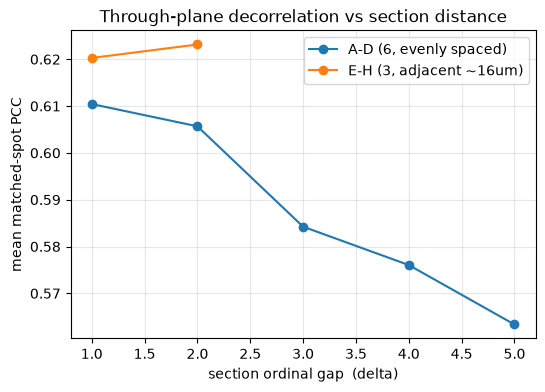

In [23]:
# Decay curves by group: A-D (6, evenly spaced) vs E-H (3, adjacent)
fig, ax = plt.subplots(figsize=(6, 4))
for label, group in [("A-D (6, evenly spaced)", "ABCD"),
                     ("E-H (3, adjacent ~16um)", "EFGH")]:
    agg = defaultdict(list)
    for s in group:
        for g, (m, n) in matched_pcc(s).items():
            agg[g].append(m)
    xs = sorted(agg); ys = [np.mean(agg[g]) for g in xs]
    ax.plot(xs, ys, 'o-', label=label)
ax.set_xlabel("section ordinal gap  (delta)")
ax.set_ylabel("mean matched-spot PCC")
ax.set_title("Through-plane decorrelation vs section distance")
ax.legend(); ax.grid(alpha=.3)
plt.show()

## Summary

- **Samples**: A-H = 8 HER2+ breast tumors. Each sample is a serial-section stack — **A-D have 6 sections (evenly spaced), E-H have 3 sections (adjacent)** — 36 sections in total.
- **Spot contents**: 250-gene log-norm expression (`label`) + grid coordinate (`position`) + H&E image features (`feature_512/1024`).
- **Distance between sections**:
  - *In-plane*: spot pitch **100 um** (1 grid step).
  - *Through-plane (z)*: section thickness **16 um**. E-H are adjacent (~16 um); A-D are evenly spaced (~32 um).
  - *Measured*: for E-H the correlation is nearly flat vs delta (~0.62 floor: at 16 um through-plane decorrelation is below the matching-noise floor), while A-D declines gently as delta grows -> A-D's interval is genuinely larger than 16 um (tens of um).

---

# ST-Data (ST_Breast_3D)

Serial-section ST dataset (2020, Nat Biomed Eng, https://www.nature.com/articles/s41551-020-0578-x)
- **"samples" are 16 numeric tumor stacks** (e.g. `23272`), not letters. Each stack has **3 sections** named `1, 2, 3`.
- Sections are **adjacent** (consecutive 16 um sections), so the through-plane gaps are all ~16 um.

Spot contents are identical to HER2 (250-gene log-norm `label`, `[x, y]` grid `position`, H&E features).
Note: for ST the H&E patches nest by stack, `cropped_imgs/patch_224/<stack>/<section>/<x>x<y>.png`
(the `img_path` stored in the npy omits the stack level).

In [24]:
DATA_ST = os.path.join(DATA, "ST_Breast_3D")
ST_NPY = os.path.join(DATA_ST, "npy_information")   # per-section spot dicts, nested by stack

def st_stacks():
    out = {}
    for s in sorted(os.listdir(ST_NPY)):
        out[s] = sorted((os.path.basename(f)[:-4]
                         for f in glob.glob(os.path.join(ST_NPY, s, "*.npy"))), key=int)
    return out

def load_st_section(stack, section):
    return list(np.load(os.path.join(ST_NPY, stack, f"{section}.npy"), allow_pickle=True))

st = st_stacks()
print(f"{len(st)} stacks; sections per stack = {sorted(set(len(v) for v in st.values()))}")
for k, v in list(st.items())[:5]:
    print(f"  {k}: {v}")
print("  ...")

16 stacks; sections per stack = [3]
  23272: ['1', '2', '3']
  23277: ['1', '2', '3']
  23377: ['1', '2', '3']
  23450: ['1', '2', '3']
  23506: ['1', '2', '3']
  ...


In [25]:
# Summary table across all ST stacks / sections
rows = []
for stk, secs in st.items():
    for sec in secs:
        d = load_st_section(stk, sec)
        pos = np.array([x['position'] for x in d])
        rows.append(dict(stack=stk, section=sec, n_spots=len(d),
                         x_range=f"{pos[:,0].min()}-{pos[:,0].max()}",
                         y_range=f"{pos[:,1].min()}-{pos[:,1].max()}",
                         n_genes=np.asarray(d[0]['label']).shape[0]))
st_summary = pd.DataFrame(rows)

agg = (st_summary.groupby('stack')
       .agg(n_sections=('section','count'), total_spots=('n_spots','sum'),
            mean_spots=('n_spots','mean')))
print(agg.to_string())
print(f"\nTotal: {st_summary['n_spots'].sum()} spots across "
      f"{st_summary['stack'].nunique()} stacks, {len(st_summary)} sections")

       n_sections  total_spots  mean_spots
stack                                     
23272           3         1691  563.666667
23277           3         1585  528.333333
23377           3         1885  628.333333
23450           3          935  311.666667
23506           3         1473  491.000000
23508           3         1455  485.000000
23567           3         1729  576.333333
23803           3         1163  387.666667
23810           3         2099  699.666667
23895           3         1470  490.000000
23903           3         1373  457.666667
23944           3         1240  413.333333
24044           3         1728  576.000000
24105           3          960  320.000000
24220           3         1297  432.333333
24223           3         1093  364.333333

Total: 23176 spots across 16 stacks, 48 sections


## Visualizing ST sections

Same spatial view as HER2: each spot at its `(x, y)` grid position, colored by mean expression.

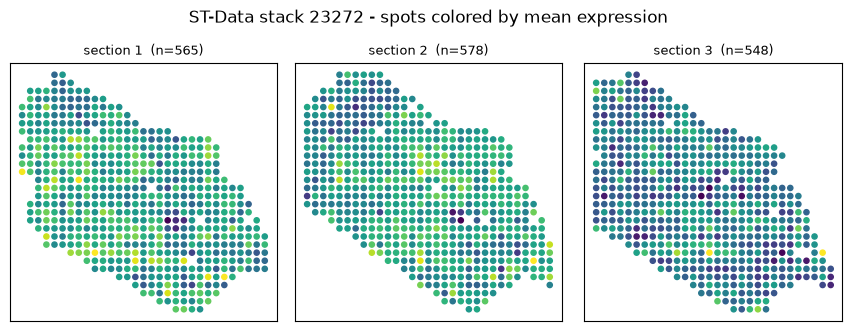

In [26]:
def plot_st_stack(stack, color_gene=None):
    secs = st[stack]
    fig, axes = plt.subplots(1, len(secs), figsize=(2.9*len(secs), 3.2), squeeze=False)
    for ax, sec in zip(axes[0], secs):
        d = load_st_section(stack, sec)
        pos = np.array([x['position'] for x in d], float)
        lab = np.array([x['label'] for x in d], float)
        c = lab[:, color_gene] if color_gene is not None else lab.mean(1)
        ax.scatter(pos[:,0], pos[:,1], c=c, s=14, cmap='viridis')
        ax.set_title(f"section {sec}  (n={len(d)})", fontsize=9)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    ttl = f"gene[{color_gene}]" if color_gene is not None else "mean expression"
    fig.suptitle(f"ST-Data stack {stack} - spots colored by {ttl}", y=1.02)
    fig.tight_layout(); plt.show()

plot_st_stack("23272")   # 3 adjacent sections

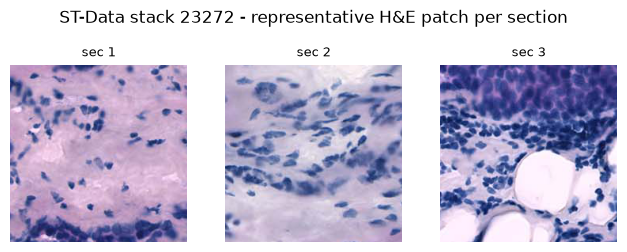

In [28]:
# One representative H&E patch per section (ST patches nest by stack)
def st_patch_path(stack, section, spot):
    x, y = spot['position']
    return os.path.join(DATA_ST, "cropped_imgs", "patch_224", stack, section, f"{x}x{y}.png")

stack = "23272"
fig, axes = plt.subplots(1, len(st[stack]), figsize=(2.2*len(st[stack]), 2.4))
for ax, sec in zip(np.atleast_1d(axes), st[stack]):
    d = load_st_section(stack, sec)
    img = Image.open(st_patch_path(stack, sec, d[0]))
    ax.imshow(img); ax.set_title(f"sec {sec}", fontsize=9); ax.axis('off')
fig.suptitle(f"ST-Data stack {stack} - representative H&E patch per section", y=1.03)
plt.tight_layout(); plt.show()

## Distance between ST sections

In-plane: same ST grid, spot pitch ~100 um. Through-plane: all sections adjacent, so every ordinal
gap corresponds to ~16 um steps. The matched-spot correlation should stay roughly flat across gaps
(at 16 um the through-plane decorrelation is below the matching-noise floor).

In [29]:
def st_matched_pcc(stack):
    secs = st[stack]
    S = {sec: {tuple(x['position']): np.asarray(x['label'], float)
               for x in load_st_section(stack, sec)} for sec in secs}
    gaps = defaultdict(list)
    for i in range(len(secs)):
        for j in range(i+1, len(secs)):
            a, b = S[secs[i]], S[secs[j]]
            for key in set(a) & set(b):
                va, vb = a[key], b[key]
                if va.std() > 0 and vb.std() > 0:
                    gaps[j-i].append(np.corrcoef(va, vb)[0, 1])
    return {g: (float(np.mean(v)), len(v)) for g, v in sorted(gaps.items())}

agg = defaultdict(list)
for stk in st:
    for g, (m, n) in st_matched_pcc(stk).items():
        agg[g].append(m)

print("ST-Data (16 stacks, adjacent ~16um) matched-spot PCC vs ordinal gap:")
for g in sorted(agg):
    print(f"  delta={g}: mean PCC = {np.mean(agg[g]):.3f}  (averaged over {len(agg[g])} stacks)")

ST-Data (16 stacks, adjacent ~16um) matched-spot PCC vs ordinal gap:
  delta=1: mean PCC = 0.642  (averaged over 16 stacks)
  delta=2: mean PCC = 0.647  (averaged over 16 stacks)
